# Edge Detection Validation

## Purpose
This notebook validates lane-related edge quality inside the fixed ROI as a prerequisite for line detection.

## Workflow
1.	Load selected test frames - use the same curated frame subset to keep comparisons consistent across runs
2.	Load ROI mask (fixed) - reuse the finalized trapezoid ROI from 02_roi_exploration without further tuning
3.	Preprocess for edges - grayscale + optional Gaussian blur to reduce noise before edge detection
4.	Compute edges - run Canny (initial thresholds), optionally compare a small set of threshold pairs
5.	Apply ROI to edges - keep only edges inside the ROI so we evaluate lane signal where it matters
6.	Visual validation on a single frame - sanity check: lane boundaries should appear as strong, mostly continuous edges
7.	Evaluate on all test frames - grid visualization per frame: original / ROI overlay / edges-in-ROI
8.	Tune edge parameters (not ROI) - adjust Canny thresholds (and blur kernel if needed) to improve lane-edge consistency
9.	Decide readiness for line detection - if edges are clean and stable across frames, proceed to Hough/line fitting; otherwise add color thresholding or further denoising

## Goal
Validate that lane boundaries produce strong, consistent edges inside the fixed ROI across diverse frames (curves, shadows, traffic, varying brightness), and tune edge-detection parameters (blur and Canny thresholds) until the edge signal is reliable enough to proceed to line detection (Hough / fitting).

## 1. Import Libraries

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import math

Total special frames: 36


## 2. Helper Functions

### 2.1 Frame display helper

In [8]:
def show_frames_grid(frames_rgb, titles=None, rows=2, cols=4, figsize=(22, 10), suptitle=None):
    plt.figure(figsize=figsize)
    for i, img in enumerate(frames_rgb):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        if titles is not None:
            plt.title(titles[i], fontsize=8, color="gray")
        plt.axis("off")
    if suptitle:
        plt.suptitle(suptitle, fontsize=18, y=1.02)
    plt.tight_layout()
    plt.show()

### 2.2 Fixed trapezoid ROI mask (same ratios as nb2 final)


In [ ]:
def apply_roi_mask(frame,
                   top_y_ratio=0.60,
                   left_bottom_ratio=0.05,
                   right_bottom_ratio=0.95,
                   top_left_x_ratio=0.40,
                   top_right_x_ratio=0.60):
    h, w = frame.shape[:2]

    pts = np.array([[
        (int(w * left_bottom_ratio),  h),
        (int(w * right_bottom_ratio), h),
        (int(w * top_right_x_ratio),  int(h * top_y_ratio)),
        (int(w * top_left_x_ratio),   int(h * top_y_ratio)),
    ]], dtype=np.int32)

    mask = np.zeros_like(frame)
    cv2.fillPoly(mask, pts, (255, 255, 255))

    masked = cv2.bitwise_and(frame, mask)
    return masked, pts

### 2.3 Draw ROI outline on an RGB frame (for visualization)

In [ ]:
def draw_roi_outline(frame_rgb, pts, color=(0, 255, 0), thickness=3):
    out = frame_rgb.copy()
    cv2.polylines(out, pts, isClosed=True, color=color, thickness=thickness)
    return out

## 3. Load ROI Test Frames


Total special frames: 36
ROI Test Frames:
  [2] frame_t109_f6540.png
  [5] frame_t12_f720.png
  [9] frame_t186_f11160.png
  [12] frame_t1_f60.png
  [18] frame_t243_f14580.png
  [23] frame_t287_f17220.png
  [29] frame_t294_f17640.png
  [35] frame_t9_f540.png


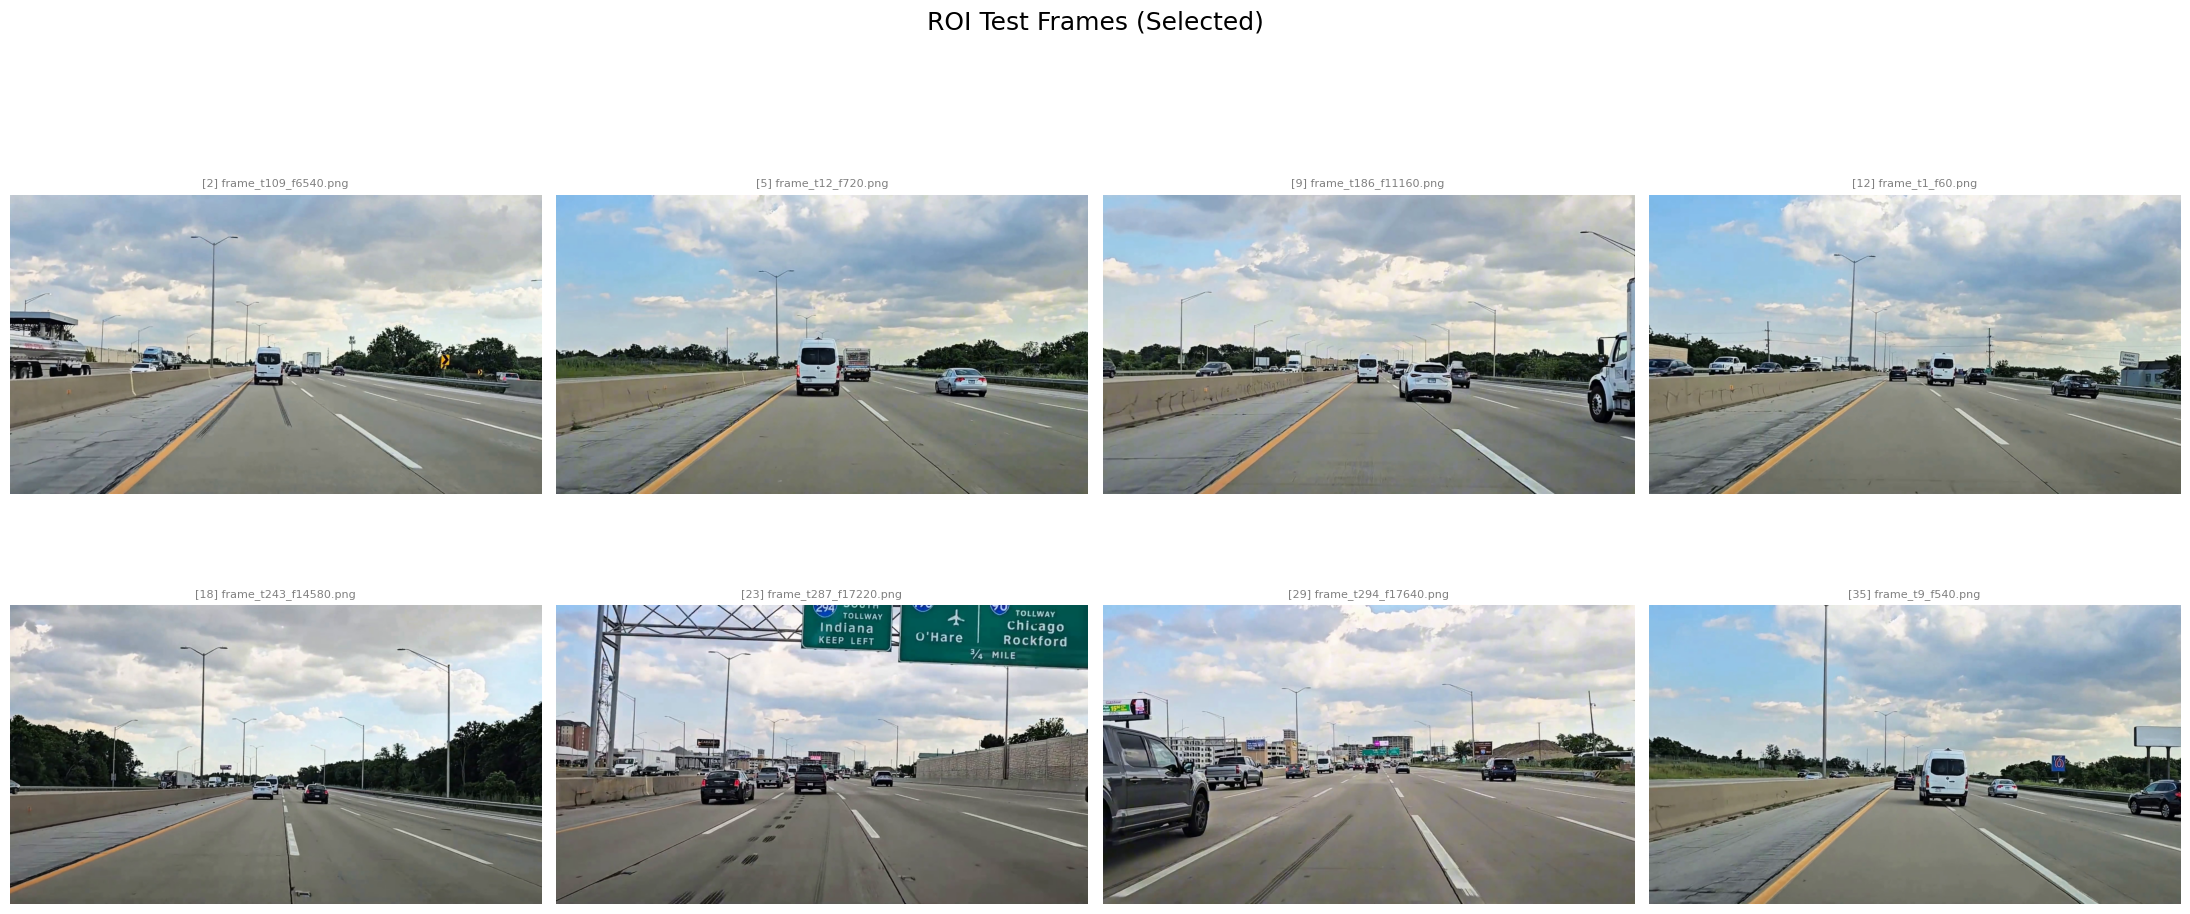

In [11]:
SPECIAL_DIR = "../data/frames_sample"
special_frames = sorted(os.listdir(SPECIAL_DIR))

print("Total special frames:", len(special_frames))

ROI_FRAME_INDICES = [2, 5, 9, 12, 18, 23, 29, 35]
ROI_FRAME_NAMES = [special_frames[i] for i in ROI_FRAME_INDICES]

print("ROI Test Frames:")
for i, name in zip(ROI_FRAME_INDICES, ROI_FRAME_NAMES):
    print(f"  [{i}] {name}")

frames_bgr = []
frames_rgb = []
for idx in ROI_FRAME_INDICES:
    path = os.path.join(SPECIAL_DIR, special_frames[idx])
    img_bgr = cv2.imread(path)
    frames_bgr.append(img_bgr)
    frames_rgb.append(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))

titles = [f"[{i}] {special_frames[i]}" for i in ROI_FRAME_INDICES]
show_frames_grid(frames_rgb, titles=titles, rows=2, cols=4, suptitle="ROI Test Frames (Selected)")

## 4. Load Fixed ROI Mask Function


In [ ]:
# Create ROI polygon (pts) once, using the shape of a frame (all frames same size)
dummy_edges = np.zeros(frames_bgr[0].shape[:2], dtype=np.uint8)
_, roi_pts = apply_roi_mask_single_channel(dummy_edges)

## 5. Test Edge Pipeline on Single Frame


In [ ]:
test_idx = 2
frame_bgr = frames_bgr[test_idx]
frame_rgb = frames_rgb[test_idx]

# Grayscale + blur + Canny
gray = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

low, high = 50, 150
edges = cv2.Canny(blur, low, high)

# Apply the fixed ROI (from nb2) to the edges
edges_roi, roi_pts = apply_roi_mask(edges)

# Visualize: original + ROI outline + edges in ROI
roi_overlay = draw_roi_outline(frame_rgb, roi_pts)

plt.figure(figsize=(16, 5))

plt.subplot(1, 3, 1)
plt.imshow(frame_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(roi_overlay)
plt.title("Original + ROI outline")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(edges_roi, cmap="gray")
plt.title(f"Edges in ROI (Canny {low},{high})")
plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Evaluate on All Test Frames

In [ ]:
edges_roi_list = []
roi_overlay_list = []

for bgr, rgb in zip(frames_bgr, frames_rgb):
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blur, low, high)
    edges_roi, _ = apply_roi_mask_single_channel(edges)

    roi_overlay_list.append(draw_roi_outline(rgb, roi_pts))
    edges_roi_list.append(edges_roi)

show_frames_grid(
    roi_overlay_list,
    titles=titles,
    rows=2,
    cols=4,
    suptitle="ROI Outline on Test Frames"
)

#  Show edges-in-ROI (convert to displayable grayscale):

plt.figure(figsize=(22, 10))
for i, e in enumerate(edges_roi_list):
    plt.subplot(2, 4, i + 1)
    plt.imshow(e, cmap="gray")
    plt.title(titles[i], fontsize=8, color="gray")
    plt.axis("off")
plt.suptitle(f"Edges in ROI (Canny {low},{high})", fontsize=18, y=1.02)
plt.tight_layout()
plt.show()

## 7. Tune Edge Parameters (Small Grid Search)


In [ ]:
canny_pairs = [(30, 100), (50, 150), (70, 200)]
test_idx = 0
bgr = frames_bgr[test_idx]
rgb = frames_rgb[test_idx]

gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

plt.figure(figsize=(18, 5))
for j, (lo, hi) in enumerate(canny_pairs):
    edges = cv2.Canny(blur, lo, hi)
    edges_roi, _ = apply_roi_mask_single_channel(edges)

    plt.subplot(1, len(canny_pairs), j + 1)
    plt.imshow(edges_roi, cmap="gray")
    plt.title(f"Canny ({lo},{hi})")
    plt.axis("off")

plt.suptitle("Threshold Sensitivity (Single Frame)", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

## 8. Findings

	•	Edges inside ROI are continuous for lane boundaries across the selected frames.
	•	Non-lane road markings can produce strong edges and may be parallel to lane lines.
	•	Therefore, slope-only filtering is insufficient - lane detection will require structural constraints (left/right pair selection, lane-width constraint) and/or temporal smoothing (video).